## 1.Import Required libraries

In [3]:
pip install lightgbm


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



     ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
     - -------------------------------------- 0.1/1.4 MB 1.3 MB/s eta 0:00:02
     --- ------------------------------------ 0.1/1.4 MB 1.2 MB/s eta 0:00:02
     ---------- ----------------------------- 0.3/1.4 MB 2.2 MB/s eta 0:00:01
     ----------------- ---------------------- 0.6/1.4 MB 2.9 MB/s eta 0:00:01
     -------------------------- ------------- 0.9/1.4 MB 4.0 MB/s eta 0:00:01
     ---------------------------------------- 1.4/1.4 MB 5.1 MB/s eta 0:00:00
     ---------------------------------------- 0.0/461.0 kB ? eta -:--:--
     ------------------------------------- 461.0/461.0 kB 28.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier

import warnings
warnings.filterwarnings("ignore")

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_score,recall_score

## 2.Data Collection

In [3]:
credit_card_data = pd.read_csv("credit_card_clean.csv")
credit_card_data

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,20000.0,female,university,married,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,female,university,single,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,female,university,single,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,female,university,married,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,male,university,married,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,male,highschool,married,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,male,highschool,single,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,male,university,single,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,male,highschool,married,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


## 3.Data Understanding

### Exploring the variable
* ID : ID of each client

* LIMIT_BAL: Amount of given credit in NT dollars (includes individual and family/supplementary credit)

* SEX: Gender (1=male, 2=female)

* EDUCATION: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)

* MARRIAGE: Marital status (1=married, 2=single, 3=others)

* AGE: Age in years

* PAY_1: Repayment status in September, 2005 (-2 = No consumption, -1 = paid in full, 0 = use of revolving credit (paid minimum only), 1 = payment delay for one month, 2 = payment delay for two months, ... 8 = payment delay for eight months, 9 = payment delay for nine months and above)

* PAY_2: Repayment status in August, 2005 (scale same as above)

* PAY_3: Repayment status in July, 2005 (scale same as above)

* PAY_4: Repayment status in June, 2005 (scale same as above)

* PAY_5: Repayment status in May, 2005 (scale same as above)

* PAY_6: Repayment status in April, 2005 (scale same as above)

* BILL_AMT1: Amount of bill statement in September, 2005 (NT dollar)

* BILL_AMT2: Amount of bill statement in August, 2005 (NT dollar)

* BILL_AMT3: Amount of bill statement in July, 2005 (NT dollar)

* BILL_AMT4: Amount of bill statement in June, 2005 (NT dollar)

* BILL_AMT5: Amount of bill statement in May, 2005 (NT dollar)

* BILL_AMT6: Amount of bill statement in April, 2005 (NT dollar)

* PAY_AMT1: Amount of previous payment in September, 2005 (NT dollar)

* PAY_AMT2: Amount of previous payment in August, 2005 (NT dollar)

* PAY_AMT3: Amount of previous payment in July, 2005 (NT dollar)

* PAY_AMT4: Amount of previous payment in June, 2005 (NT dollar)

* PAY_AMT5: Amount of previous payment in May, 2005 (NT dollar)

* PAY_AMT6: Amount of previous payment in April, 2005 (NT dollar)

#### Target variable
default.payment.next.month: Default payment (1=yes, 0=no)

###### Note: NT is Taiwain Dollars

In [4]:
credit_card_data.isna().sum()

ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_1        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
DEFAULT      0
dtype: int64

In [5]:
credit_card_data.dtypes

ID             int64
LIMIT_BAL    float64
SEX           object
EDUCATION     object
MARRIAGE      object
AGE            int64
PAY_1          int64
PAY_2          int64
PAY_3          int64
PAY_4          int64
PAY_5          int64
PAY_6          int64
BILL_AMT1    float64
BILL_AMT2    float64
BILL_AMT3    float64
BILL_AMT4    float64
BILL_AMT5    float64
BILL_AMT6    float64
PAY_AMT1     float64
PAY_AMT2     float64
PAY_AMT3     float64
PAY_AMT4     float64
PAY_AMT5     float64
PAY_AMT6     float64
DEFAULT        int64
dtype: object

In [6]:
credit_card_data.shape

(30000, 25)

## 4.Data Preparation

### Dropping the ID column.Since, it is unnecessary

In [7]:
credit_card_data.drop("ID",axis=1,inplace=True)

### Now need to convert the Object dtype columns to numeric

In [9]:
le = LabelEncoder()
credit_card_data["SEX"]=le.fit_transform(credit_card_data.SEX)
credit_card_data["EDUCATION"]=le.fit_transform(credit_card_data.EDUCATION)
credit_card_data["MARRIAGE"]=le.fit_transform(credit_card_data.MARRIAGE)

credit_card_data

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000.0,0,3,0,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,0,3,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,0,3,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,0,3,0,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,3,0,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000.0,1,1,0,39,0,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,150000.0,1,1,2,43,-1,-1,-1,-1,0,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,30000.0,1,3,2,37,4,3,2,-1,0,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,80000.0,1,1,0,41,1,-1,0,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


In [10]:
credit_card_data.dtypes

LIMIT_BAL    float64
SEX            int64
EDUCATION      int64
MARRIAGE       int64
AGE            int64
PAY_1          int64
PAY_2          int64
PAY_3          int64
PAY_4          int64
PAY_5          int64
PAY_6          int64
BILL_AMT1    float64
BILL_AMT2    float64
BILL_AMT3    float64
BILL_AMT4    float64
BILL_AMT5    float64
BILL_AMT6    float64
PAY_AMT1     float64
PAY_AMT2     float64
PAY_AMT3     float64
PAY_AMT4     float64
PAY_AMT5     float64
PAY_AMT6     float64
DEFAULT        int64
dtype: object

## 5.Model Building

In [11]:
X=credit_card_data.drop("DEFAULT",axis=1)
y=credit_card_data["DEFAULT"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=123,shuffle=True,stratify=y)

In [13]:
X_train.shape,y_train.shape

((24000, 23), (24000,))

In [14]:
X_test.shape,y_test.shape

((6000, 23), (6000,))

## 6.Model Training

In [32]:
ab_classifier = AdaBoostClassifier(n_estimators=100)
gb_classifier = GradientBoostingClassifier(n_estimators=100)
xgb_classifier =XGBClassifier(n_estimators=100)
lgbm_classifer = LGBMClassifier(n_estimators=100)

In [33]:
%%time
ab_classifier.fit(X_train,y_train)

CPU times: total: 8.2 s
Wall time: 8.89 s


,estimator,None
,n_estimators,100
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


In [34]:
%%time
gb_classifier.fit(X_train,y_train)

CPU times: total: 21.3 s
Wall time: 22.8 s


,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [35]:
%%time
xgb_classifier.fit(X_train,y_train)

CPU times: total: 3.7 s
Wall time: 468 ms


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [36]:
%%time
lgbm_classifer.fit(X_train,y_train)

[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004990 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3259
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221208 -> initscore=-1.258639
[LightGBM] [Info] Start training from score -1.258639
CPU times: total: 2.58 s
Wall time: 330 ms


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## 7.Model Testing

In [37]:
y_pred_ab = ab_classifier.predict(X_test)
y_pred_gb  = gb_classifier.predict(X_test)
y_pred_xgb = xgb_classifier.predict(X_test)
y_pred_lgb=lgbm_classifer.predict(X_test)

## 8.Model Evaluation

### For Adaboost

In [21]:
print("Accuracy Score:",round(accuracy_score(y_test,y_pred_ab),4))
print("Precision Score:",round(precision_score(y_test,y_pred_ab),4))
print("Recall Score",round(recall_score(y_test,y_pred_ab)),4)
print("Confusion Matrix\n",confusion_matrix(y_test,y_pred_ab))

Accuracy Score: 0.8208
Precision Score: 0.7
Recall Score 0 4
Confusion Matrix
 [[4484  189]
 [ 886  441]]


### For GradientBoost

In [22]:
print("Accuracy Score:",round(accuracy_score(y_test,y_pred_gb),4))
print("Precision Score:",round(precision_score(y_test,y_pred_gb),4))
print("Recall Score",round(recall_score(y_test,y_pred_gb)),4)
print("Confusion Matrix\n",confusion_matrix(y_test,y_pred_gb))

Accuracy Score: 0.823
Precision Score: 0.6912
Recall Score 0 4
Confusion Matrix
 [[4459  214]
 [ 848  479]]


### For XGBM

In [23]:
print("Accuracy Score:",round(accuracy_score(y_test,y_pred_xgb),4))
print("Precision Score:",round(precision_score(y_test,y_pred_xgb),4))
print("Recall Score",round(recall_score(y_test,y_pred_xgb)),4)
print("Confusion Matrix\n",confusion_matrix(y_test,y_pred_xgb))

Accuracy Score: 0.8118
Precision Score: 0.6327
Recall Score 0 4
Confusion Matrix
 [[4399  274]
 [ 855  472]]


### For LGBM

In [24]:
print("Accuracy Score:",round(accuracy_score(y_test,y_pred_lgb),4))
print("Precision Score:",round(precision_score(y_test,y_pred_lgb),4))
print("Recall Score",round(recall_score(y_test,y_pred_lgb)),4)
print("Confusion Matrix\n",confusion_matrix(y_test,y_pred_lgb))

Accuracy Score: 0.825
Precision Score: 0.6981
Recall Score 0 4
Confusion Matrix
 [[4462  211]
 [ 839  488]]


## Feature Importance

In [39]:
ab_feature_imp   = ab_classifier.feature_importances_
gb_feature_imp   = gb_classifier.feature_importances_
xgbb_feature_imp = xgb_classifier.feature_importances_
lgb_feature_imp = lgbm_classifer.feature_importances_

In [40]:
X.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'],
      dtype='object')

In [43]:
feature_importance=pd.DataFrame(data={"Features": X.columns,
                   "AB features":ab_feature_imp,
                  "GB features":gb_feature_imp,
                  "XGBM Features":xgbb_feature_imp,
                  "LGBM Features":lgb_feature_imp},)

In [44]:
feature_importance["AB features"]

0     0.046151
1     0.011644
2     0.000000
3     0.014302
4     0.000000
5     0.471914
6     0.040138
7     0.047040
8     0.024340
9     0.014272
10    0.034110
11    0.035018
12    0.020681
13    0.004518
14    0.002167
15    0.014881
16    0.000000
17    0.090115
18    0.065198
19    0.035035
20    0.015765
21    0.003018
22    0.009692
Name: AB features, dtype: float64

## Top 10 Adaboost features

In [55]:
Adaboost_top_features = feature_importance.sort_values(by="AB features",ascending=False).head(10)
Adaboost_top_features

,Features,AB features,GB features,XGBM Features,LGBM Features
5,PAY_1,0.471914,0.616414,0.385151,98
17,PAY_AMT1,0.090115,0.022847,0.022604,170
18,PAY_AMT2,0.065198,0.020449,0.021563,205
7,PAY_3,0.047040,0.040526,0.051788,52
0,LIMIT_BAL,0.046151,0.031110,0.023477,236
6,PAY_2,0.040138,0.088202,0.098940,44
19,PAY_AMT3,0.035035,0.021685,0.026277,177
11,BILL_AMT1,0.035018,0.029573,0.023916,213
10,PAY_6,0.034110,0.018229,0.037504,50
8,PAY_4,0.024340,0.015739,0.039132,36


<Axes: xlabel='AB features', ylabel='Features'>

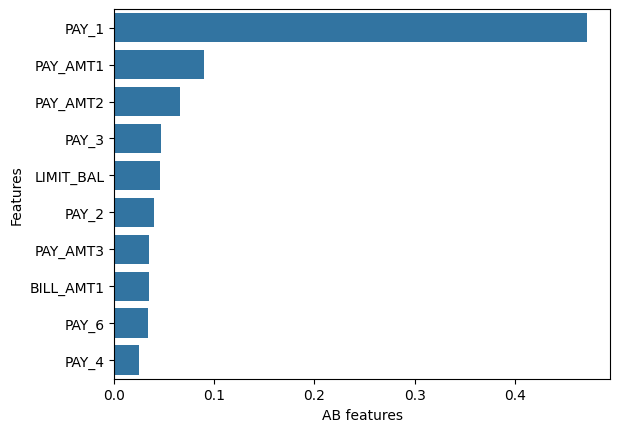

In [59]:
import seaborn as sns
sns.barplot(data=Adaboost_top_features,y="Features",x="AB features")

## Top 10 Gradient Boost Features

In [60]:
Gboost_top_features = feature_importance.sort_values(by="GB features",ascending=False).head(10)
Gboost_top_features

,Features,AB features,GB features,XGBM Features,LGBM Features
5,PAY_1,0.471914,0.616414,0.385151,98
6,PAY_2,0.040138,0.088202,0.098940,44
7,PAY_3,0.047040,0.040526,0.051788,52
0,LIMIT_BAL,0.046151,0.031110,0.023477,236
11,BILL_AMT1,0.035018,0.029573,0.023916,213
17,PAY_AMT1,0.090115,0.022847,0.022604,170
19,PAY_AMT3,0.035035,0.021685,0.026277,177
18,PAY_AMT2,0.065198,0.020449,0.021563,205
10,PAY_6,0.034110,0.018229,0.037504,50
8,PAY_4,0.024340,0.015739,0.039132,36


<Axes: xlabel='GB features', ylabel='Features'>

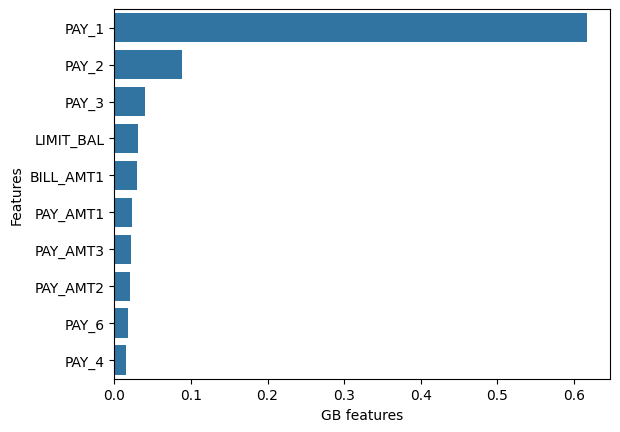

In [61]:
sns.barplot(data=Gboost_top_features,y="Features",x="GB features")

## Top 10 XGBM Features

In [63]:
XGboost_top_features = feature_importance.sort_values(by="XGBM Features",ascending=False).head(10)
XGboost_top_features

,Features,AB features,GB features,XGBM Features,LGBM Features
5,PAY_1,0.471914,0.616414,0.385151,98
6,PAY_2,0.040138,0.088202,0.098940,44
7,PAY_3,0.047040,0.040526,0.051788,52
8,PAY_4,0.024340,0.015739,0.039132,36
10,PAY_6,0.034110,0.018229,0.037504,50
9,PAY_5,0.014272,0.012933,0.035801,38
19,PAY_AMT3,0.035035,0.021685,0.026277,177
11,BILL_AMT1,0.035018,0.029573,0.023916,213
0,LIMIT_BAL,0.046151,0.031110,0.023477,236
17,PAY_AMT1,0.090115,0.022847,0.022604,170


<Axes: xlabel='XGBM Features', ylabel='Features'>

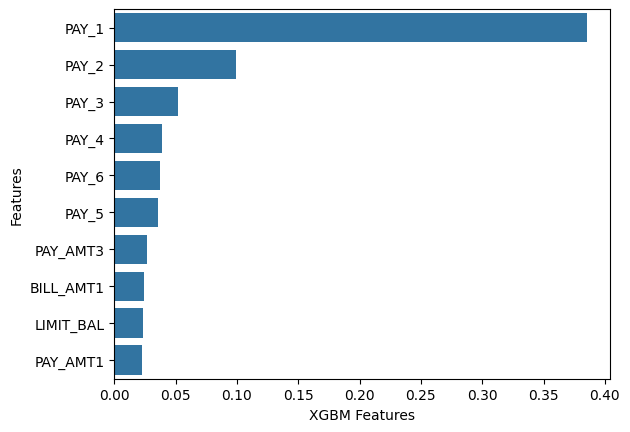

In [64]:
sns.barplot(data=XGboost_top_features,y="Features",x="XGBM Features")

## TOP 10 LGBM Features

In [65]:
LGboost_top_features = feature_importance.sort_values(by="LGBM Features",ascending=False).head(10)
LGboost_top_features

,Features,AB features,GB features,XGBM Features,LGBM Features
0,LIMIT_BAL,0.046151,0.031110,0.023477,236
22,PAY_AMT6,0.009692,0.010356,0.020814,233
4,AGE,0.000000,0.007494,0.018393,217
11,BILL_AMT1,0.035018,0.029573,0.023916,213
18,PAY_AMT2,0.065198,0.020449,0.021563,205
19,PAY_AMT3,0.035035,0.021685,0.026277,177
12,BILL_AMT2,0.020681,0.009929,0.021107,173
17,PAY_AMT1,0.090115,0.022847,0.022604,170
13,BILL_AMT3,0.004518,0.007777,0.020650,161
21,PAY_AMT5,0.003018,0.005878,0.018832,161


<Axes: xlabel='LGBM Features', ylabel='Features'>

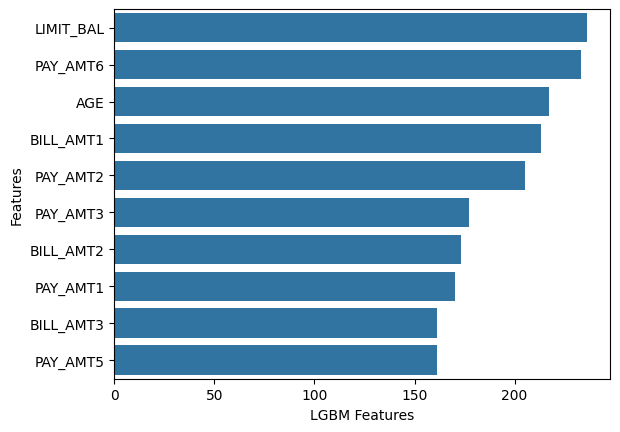

In [66]:
sns.barplot(data=LGboost_top_features,y="Features",x="LGBM Features")

## THE END!!